# Krytyk Strykera — PROTOTYP (Opcja A, 1000 par)

## Cel prototypu
Sprawdzic w ~15 min, czy pairwise ranking loss uczy sie sensownie NA NASZYCH danych, ZANIM odpalimy pelny trening ViT-L na 14k parach.

Trzy pytania:
1. Czy strata spada i pairwise accuracy rosnie powyzej baseline 59% (os liniowa)?
2. Czy jest generalizacja (test acc > baseline), czy tylko przeuczenie (train rosnie, test nie)?
3. Czy higiena dziurek dziala (inpainting usuwa skrot)?

## Architektura (stopniowa)
- **Faza 1**: glowa MLP na ZAMROZONYM CLIP (najszybsza — izoluje pytanie o wydobywalnosc sygnalu)
- **Faza 2** (przelacznik): LoRA na wiezy wizyjnej, gdy glowa nie wystarcza
- Przelacznik `BACKBONE`: 'ViT-B-32' (szybki prototyp) lub 'ViT-L-14' (finalowy)

## Strata: margin ranking
`L = max(0, margin - (score(chosen) - score(rejected)))` — para tej samej sceny kasuje konfoundy sceniczne.


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch 2>/dev/null


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, open_clip
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
np.set_printoptions(precision=4, suppress=True)
torch.manual_seed(42); np.random.seed(42)

DRIVE = Path('/content/drive/MyDrive/fsa_data')
PAIRS = DRIVE/'fsa_pairs_filtered.csv'
IMAGES_DRIVE = DRIVE/'fsa_images'
IMAGES_LOCAL = Path('/content/fsa_images_local')
SRC = IMAGES_LOCAL if IMAGES_LOCAL.exists() else IMAGES_DRIVE
HOLE_CACHE = DRIVE/'hole_detection_cache.csv'

# ===== PRZELACZNIKI =====
BACKBONE = 'ViT-B-32'      # prototyp; finalowo 'ViT-L-14'
PRETRAINED = 'laion2b_s34b_b79k'   # dla ViT-L-14: 'laion2b_s32b_b82k'
N_PAIRS = 14000            # prototyp
USE_LORA = False          # Faza 1: glowa na zamrozonym CLIP
HYGIENE = False            # inpainting dziurek

device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device=='cuda', 'Wymaga GPU'
print(f'Backbone={BACKBONE}, par={N_PAIRS}, LoRA={USE_LORA}, higiena={HYGIENE}, {device}')


Backbone=ViT-B-32, par=14000, LoRA=False, higiena=False, cuda


## 1. Wczytaj CLIP + pary + detekcja dziurek

In [3]:
model, _, preprocess = open_clip.create_model_and_transforms(BACKBONE, pretrained=PRETRAINED)
model = model.to(device).eval()
for p in model.parameters(): p.requires_grad = False  # domyslnie zamrozony
EMB_DIM = model.visual.output_dim
print(f'CLIP {BACKBONE}, emb_dim={EMB_DIM}')

pairs = pd.read_csv(PAIRS, dtype={'similarity':float}, keep_default_na=False)
# Podprobka 1000 par, zachowujac rozklad sim_level
pairs = pairs.groupby('sim_level', group_keys=False).apply(
    lambda g: g.sample(min(len(g), int(N_PAIRS*len(g)/len(pairs))+1), random_state=42)
).reset_index(drop=True).head(N_PAIRS)
print(f'Podprobka: {len(pairs)} par, rozklad:')
print(pairs['sim_level'].value_counts().to_string())

# Mapa dziurek (do inpaintingu)
hole_df = pd.read_csv(HOLE_CACHE) if HOLE_CACHE.exists() else pd.DataFrame(columns=['file','has_hole','cx','cy','radius'])
hole_map = {r['file']: r for _,r in hole_df[hole_df['has_hole']==True].iterrows()}
print(f'Dziurki w cache: {len(hole_map)}')


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

CLIP ViT-B-32, emb_dim=512


/tmp/ipykernel_6478/3536668622.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairs = pairs.groupby('sim_level', group_keys=False).apply(


Podprobka: 14000 par, rozklad:
sim_level
bliski       6445
wyrazny      5480
mikroruch    2075
Dziurki w cache: 1098


## 2. Loader z inpaintingiem dziurek (higiena u zrodla)

In [4]:
def load_hygienic(fname):
    """Wczytaj obraz; jesli ma dziurke w cache -> inpaint PRZED CLIP."""
    img = cv2.imread(str(SRC/fname))
    if HYGIENE and fname in hole_map:
        h = hole_map[fname]
        mask = np.zeros(img.shape[:2], np.uint8)
        cv2.circle(mask, (int(h['cx']),int(h['cy'])), int(h['radius'])+4, 255, -1)
        img = cv2.inpaint(img, mask, 5, cv2.INPAINT_TELEA)
    return Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

@torch.no_grad()
def embed_files(fnames, bs=64):
    """CLIP embedding listy plikow (z higiena). Zwraca tensor na GPU."""
    out = []
    for i in range(0, len(fnames), bs):
        chunk = fnames[i:i+bs]
        t = torch.stack([preprocess(load_hygienic(f)) for f in chunk]).to(device)
        e = model.encode_image(t); e = e/e.norm(dim=-1,keepdim=True)
        out.append(e.float())
    return torch.cat(out)

# Policz embeddingi chosen i rejected RAZ (zamrozony CLIP -> cache w pamieci)
print('Liczę embeddingi (z inpaintingiem dziurek)...')
E_chosen = embed_files(pairs['chosen_file'].tolist())
E_reject = embed_files(pairs['rejected_file'].tolist())
print(f'Embeddingi: chosen {tuple(E_chosen.shape)}, rejected {tuple(E_reject.shape)}')


Liczę embeddingi (z inpaintingiem dziurek)...
Embeddingi: chosen (14000, 512), rejected (14000, 512)


## 3. Split + glowa scoringowa + margin ranking loss

In [5]:
n = len(pairs)
perm = np.random.RandomState(42).permutation(n)
ntr = int(0.7*n)
tr, te = perm[:ntr], perm[ntr:]
sim_arr = pairs['sim_level'].values
print(f'Train {len(tr)}, Test {len(te)} par')

class ScoreHead(nn.Module):
    """Maly MLP: embedding -> skalar score."""
    def __init__(self, dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

head = ScoreHead(EMB_DIM).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-2)
MARGIN = 0.2

def pairwise_acc(idx):
    head.eval()
    with torch.no_grad():
        sc = head(E_chosen[idx]) - head(E_reject[idx])
    return (sc > 0).float().mean().item()

print(f'Glowa: {sum(p.numel() for p in head.parameters())} parametrow, margin={MARGIN}')


Train 9800, Test 4200 par
Glowa: 131585 parametrow, margin=0.2


## 4. Trening + krzywe uczenia

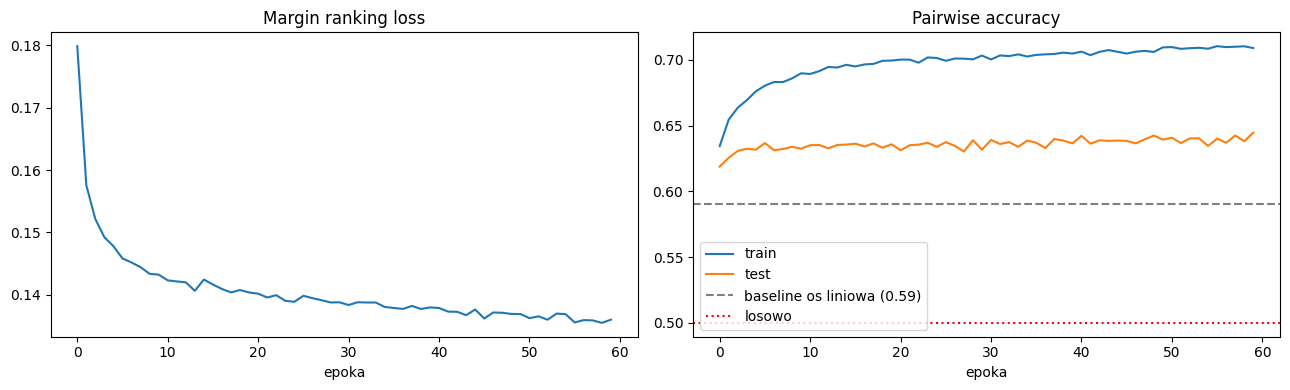

Final: train acc=0.709, test acc=0.645


In [7]:
EPOCHS = 60; BS = 128
tr_t = torch.tensor(tr)
hist = {'loss':[], 'tr_acc':[], 'te_acc':[]}
for ep in range(EPOCHS):
    head.train()
    perm_ep = tr_t[torch.randperm(len(tr_t))]
    ep_loss = 0
    for i in range(0, len(perm_ep), BS):
        b = perm_ep[i:i+BS]
        sc_c = head(E_chosen[b]); sc_r = head(E_reject[b])
        loss = torch.clamp(MARGIN - (sc_c - sc_r), min=0).mean()  # margin ranking
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item()*len(b)
    hist['loss'].append(ep_loss/len(perm_ep))
    hist['tr_acc'].append(pairwise_acc(tr))
    hist['te_acc'].append(pairwise_acc(te))

fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].plot(hist['loss']); ax[0].set_title('Margin ranking loss'); ax[0].set_xlabel('epoka')
ax[1].plot(hist['tr_acc'], label='train'); ax[1].plot(hist['te_acc'], label='test')
ax[1].axhline(0.59, color='gray', ls='--', label='baseline os liniowa (0.59)')
ax[1].axhline(0.5, color='red', ls=':', label='losowo')
ax[1].set_title('Pairwise accuracy'); ax[1].set_xlabel('epoka'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Final: train acc={hist['tr_acc'][-1]:.3f}, test acc={hist['te_acc'][-1]:.3f}")


## 5. Werdykt prototypu + test spojnosci per sim_level

In [8]:
best_te = max(hist['te_acc'])
final_te = hist['te_acc'][-1]; final_tr = hist['tr_acc'][-1]
gap = final_tr - final_te
print('='*56)
print('WERDYKT PROTOTYPU')
print('='*56)
print(f'Najlepsza test acc:    {best_te:.3f}  (baseline os liniowa 0.59)')
print(f'Final train/test:      {final_tr:.3f} / {final_te:.3f}  (gap {gap:+.3f})')
print()
if best_te > 0.62:
    print('-> MECHANIZM DZIALA: krytyk bije baseline liniowy. Warto skalowac do 14k + ViT-L.')
elif best_te > 0.55:
    print('-> SLABY sygnal ponad baseline. Wiecej danych/LoRA moze pomoc, ale ostroznie.')
else:
    print('-> BRAK przewagi nad baseline. Glowa nie wydobywa nieliniowego sygnalu.')
if gap > 0.15:
    print(f'   UWAGA: duzy gap train-test ({gap:.2f}) = przeuczenie (spodziewane na 1000 par).')

# Test spojnosci: pairwise acc per poziom (czy gradient przetrwal)
print('\nPairwise acc per sim_level (test):')
for lvl in ['mikroruch','bliski','wyrazny']:
    m = np.array([i for i in te if sim_arr[i]==lvl])
    if len(m)>5:
        print(f'  {lvl:10}: {pairwise_acc(m):.3f}  (n={len(m)})')
print('  gradient rosnacy mikroruch->wyrazny = krytyk lapie MOMENT, nie skrot')


WERDYKT PROTOTYPU
Najlepsza test acc:    0.645  (baseline os liniowa 0.59)
Final train/test:      0.709 / 0.645  (gap +0.064)

-> MECHANIZM DZIALA: krytyk bije baseline liniowy. Warto skalowac do 14k + ViT-L.

Pairwise acc per sim_level (test):
  mikroruch : 0.548  (n=633)
  bliski    : 0.638  (n=1870)
  wyrazny   : 0.688  (n=1697)
  gradient rosnacy mikroruch->wyrazny = krytyk lapie MOMENT, nie skrot


## 6. Kontrola higieny — czy surowe dane ucza sie SZYBCIEJ (lekcja nr 1)

In [9]:
# Opcjonalny test: przelacz HYGIENE=False, przelicz embeddingi, wytrenuj ponownie.
# Jesli surowe (z dziurkami) osiagaja wyzsza train acc szybciej -> model lapie dziurke.
print('Aby przetestowac wplyw higieny:')
print('1. Ustaw HYGIENE=False w komorce 0, uruchom 0-5 ponownie')
print('2. Porownaj krzywe: surowe ucza sie szybciej? -> dziurka jest skrotem (lekcja nr 1)')
print('3. Wroc do HYGIENE=True do wlasciwego treningu')
print()
print(f'Obecnie: HYGIENE={HYGIENE}, dziurek w probce: '
      f"{sum(1 for f in pairs['rejected_file'] if f in hole_map)}")


Aby przetestowac wplyw higieny:
1. Ustaw HYGIENE=False w komorce 0, uruchom 0-5 ponownie
2. Porownaj krzywe: surowe ucza sie szybciej? -> dziurka jest skrotem (lekcja nr 1)
3. Wroc do HYGIENE=True do wlasciwego treningu

Obecnie: HYGIENE=False, dziurek w probce: 1079


## 7. Nastepny krok

Jesli prototyp pokazal przewage nad baseline (test acc > 0.62) BEZ katastrofalnego przeuczenia:
- przelacz `BACKBONE='ViT-L-14'`, `N_PAIRS` na pelne 14266, `USE_LORA=True`
- dodaj LoRA na warstwy uwagi wiezy wizyjnej (trening backbone, nie tylko glowy)
- wiecej epok + early stopping po test acc

Jesli prototyp NIE bije baseline — sygnal moze byc czysto liniowy (juz go mamy w osi), a fine-tuning nie doda wartosci. To tez wynik: potwierdza, ze d'=0.188 to nie tylko granica liniowa, ale granica sygnalu.
